# 07 · Final Test-Set Evaluation (single run) & SHAP Explainability

**Owners:** Riya & Praveen

Every decision is now **frozen** — model weights (05), calibration and τ* (06), baselines (03). This notebook loads the test split for the first and only time (`load_splits(include_test=True)`) and evaluates everything **once**. Nothing below is tuned on the test set; re-running it just reproduces the same numbers.

In [1]:
# ── Environment setup: works on Google Colab (Drive) AND locally (VS Code / Jupyter) ──
import os, sys

try:
    from google.colab import drive  # only importable inside a Colab runtime
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/telco-churn-dashboard'
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    _cwd = os.path.abspath(os.getcwd())
    PROJECT_ROOT = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'notebooks' else _cwd

os.makedirs(PROJECT_ROOT, exist_ok=True)
os.chdir(PROJECT_ROOT)                      # every relative path is now project-relative
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)        # lets us `import src...`
print('Project root:', PROJECT_ROOT, '| running on Colab:', IN_COLAB)

Project root: /Users/friday/Desktop/nndl/telco-churn-dashboard | running on Colab: False


In [2]:
# Colab already ships torch, numpy, pandas, scikit-learn, matplotlib and seaborn.
# Install the extras once per Colab session (skipped automatically when running locally).
if IN_COLAB:
    %pip install -q imbalanced-learn shap fastapi uvicorn jinja2 python-multipart joblib

In [3]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import Markdown, display

from src import config
from src import plotting as P
from src.calibration import PlattCalibrator
from src.cost_optimizer import CostParams, format_currency, savings_summary
from src.data_preprocessing import get_feature_origins, load_preprocessors, load_splits
from src.explainability import ChurnExplainer, get_customer_top_drivers, select_background
from src.metrics import bootstrap_pr_auc_difference, classification_metrics, metrics_table, to_markdown_table
from src.model import CalibratedChurnModel, load_model, predict_logits
from src.numpy_perceptron import NumpyPerceptron

P.apply_style()
device = torch.device('cpu')
cfg = config.load_model_config()
missing = [k for k in ('architecture', 'imbalance_strategy', 'calibration', 'threshold', 'costs') if k not in cfg]
if missing:
    raise RuntimeError(f'model_config.json is missing {missing}; run notebooks 04-06 first.')

splits = load_splits(include_test=True)          # <- the ONLY place the test split is loaded
X_train, X_test, y_test = splits.X_train, splits.X_test, splits.y_test
tau_star = cfg['threshold']['optimal']
tau_f1 = cfg['threshold']['f1_optimal_val']
label = cfg['imbalance_strategy']['label'].split('. ', 1)[-1]
print(f'Test split: {X_test.shape[0]:,} customers, churn rate {y_test.mean():.3f}')
print(f'Frozen choices -> strategy: {label} | τ* = {tau_star:.2f} | τ_F1 (val) = {tau_f1:.2f}')

Test split: 1,409 customers, churn rate 0.265
Frozen choices -> strategy: Weighted BCE | τ* = 0.08 | τ_F1 (val) = 0.33


## 1 · Score every frozen model on the test set

In [4]:
logreg = joblib.load(config.MODELS_DIR / 'baselines' / 'logreg.pkl')
perceptron = NumpyPerceptron.load(config.MODELS_DIR / 'baselines' / 'perceptron.npz')
mlp = load_model(config.BEST_MODEL_PATH, X_test.shape[1], cfg['architecture'], device)
calibrator = PlattCalibrator.from_dict(cfg['calibration'])

p_lr = logreg.predict_proba(X_test)[:, 1]
p_slp = perceptron.predict_proba(X_test)
p_mlp = calibrator.transform(predict_logits(mlp, X_test, device=device))

mlp_name = f'MLP + {label}'
final = {
    'Logistic Regression (τ=0.50)': classification_metrics(y_test, p_lr, 0.5),
    'Single-Layer Perceptron (τ=0.50)': classification_metrics(y_test, p_slp, 0.5),
    f'{mlp_name} (τ=0.50)': classification_metrics(y_test, p_mlp, 0.5),
    f'{mlp_name} (τ_F1={tau_f1:.2f})': classification_metrics(y_test, p_mlp, tau_f1),
    f'{mlp_name} (τ*={tau_star:.2f}, deployed)': classification_metrics(y_test, p_mlp, tau_star),
}
impl = {k: {'Implementation': 'scikit-learn' if k.startswith('Logistic') else
            'Pure NumPy (from scratch)' if k.startswith('Single') else 'PyTorch + Platt calibration'}
        for k in final}
final_table = metrics_table(final, extra_columns=impl)
final_table.to_csv(config.RESULTS_DIR / 'final_test_metrics.csv')
print(to_markdown_table(final_table))
final_table

| Model | Implementation | Precision | Recall | F1 (Churn) | PR-AUC | ROC-AUC |
|---|---|---|---|---|---|---|
| Logistic Regression (τ=0.50) | scikit-learn | 0.6489 | 0.5535 | 0.5974 | 0.6340 | 0.8430 |
| Single-Layer Perceptron (τ=0.50) | Pure NumPy (from scratch) | 0.6480 | 0.5561 | 0.5986 | 0.6313 | 0.8407 |
| MLP + Weighted BCE (τ=0.50) | PyTorch + Platt calibration | 0.6512 | 0.5241 | 0.5807 | 0.6318 | 0.8415 |
| MLP + Weighted BCE (τ_F1=0.33) | PyTorch + Platt calibration | 0.5348 | 0.7193 | 0.6135 | 0.6318 | 0.8415 |
| MLP + Weighted BCE (τ*=0.08, deployed) | PyTorch + Platt calibration | 0.3718 | 0.9652 | 0.5368 | 0.6318 | 0.8415 |


,Implementation,Precision,Recall,F1 (Churn),PR-AUC,ROC-AUC
Model,,,,,,
Logistic Regression (τ=0.50),scikit-learn,0.6489,0.5535,0.5974,0.6340,0.8430
Single-Layer Perceptron (τ=0.50),Pure NumPy (from scratch),0.6480,0.5561,0.5986,0.6313,0.8407
MLP + Weighted BCE (τ=0.50),PyTorch + Platt calibration,0.6512,0.5241,0.5807,0.6318,0.8415
MLP + Weighted BCE (τ_F1=0.33),PyTorch + Platt calibration,0.5348,0.7193,0.6135,0.6318,0.8415
"MLP + Weighted BCE (τ*=0.08, deployed)",PyTorch + Platt calibration,0.3718,0.9652,0.5368,0.6318,0.8415


PR-AUC and ROC-AUC do not depend on the threshold (they are identical across the three MLP rows). Precision/recall/F1 do: the deployed τ* deliberately trades precision for recall because a missed churner costs 10× an offer.

## 2 · Is the MLP's PR-AUC really different from logistic regression's? (paired bootstrap)

In [5]:
boot = bootstrap_pr_auc_difference(y_test, p_mlp, p_lr, n_resamples=2000, seed=config.SEED)
print(f"PR-AUC(MLP) − PR-AUC(LogReg) = {boot['diff']:+.4f}")
print(f"95% bootstrap CI: [{boot['ci_low']:+.4f}, {boot['ci_high']:+.4f}]  ({boot['n_valid']} resamples)")
print(f"Share of resamples where MLP >= LogReg: {boot['p_a_better']:.1%}")

PR-AUC(MLP) − PR-AUC(LogReg) = -0.0022
95% bootstrap CI: [-0.0103, +0.0050]  (2000 resamples)
Share of resamples where MLP >= LogReg: 26.5%


## 3 · Confusion matrix at τ* and ROC / PR curves

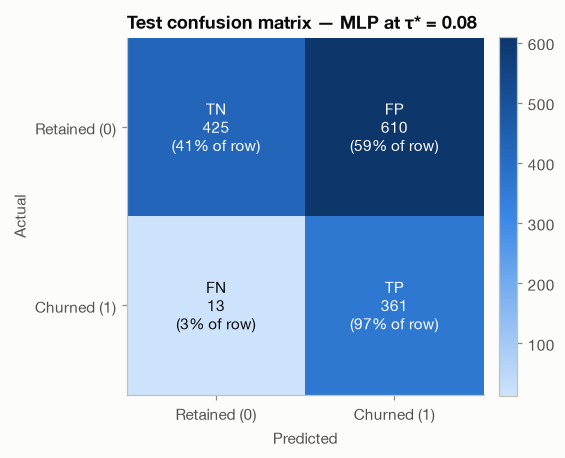

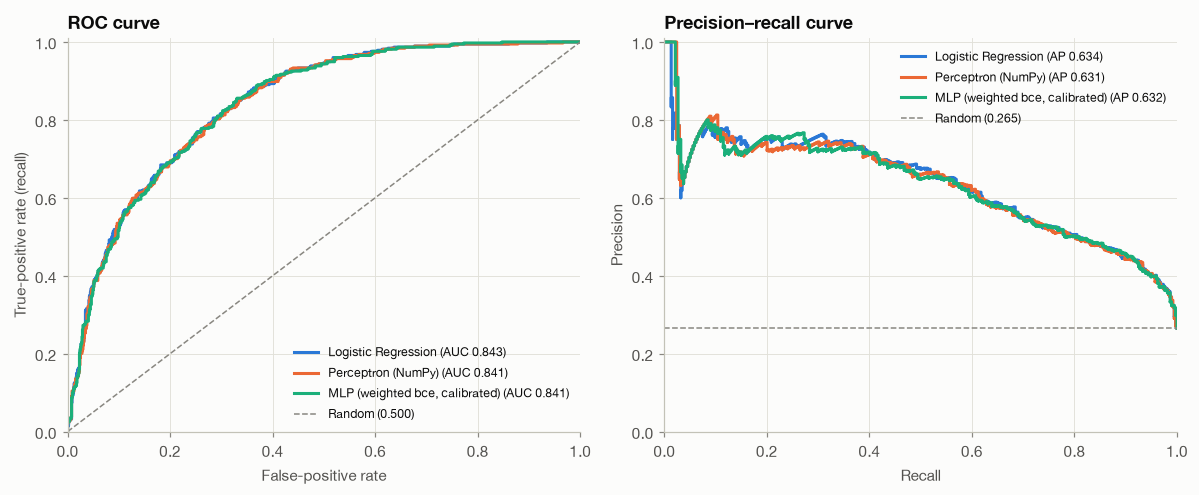

In [6]:
m_star = final[f'{mlp_name} (τ*={tau_star:.2f}, deployed)']
cm = np.array([[m_star['tn'], m_star['fp']], [m_star['fn'], m_star['tp']]])
fig = P.plot_confusion_matrix(cm, title=f'Test confusion matrix — MLP at τ* = {tau_star:.2f}')
P.save_figure(fig, config.PLOTS_DIR / 'confusion_matrix.png')
plt.show()

fig = P.plot_roc_pr_curves({
    'Logistic Regression': (y_test, p_lr),
    'Perceptron (NumPy)': (y_test, p_slp),
    f'MLP ({label.lower()}, calibrated)': (y_test, p_mlp),
}, positive_rate=float(y_test.mean()))
P.save_figure(fig, config.PLOTS_DIR / 'roc_pr_curves.png')
plt.show()

## 4 · Business cost on the test set

In [7]:
params = CostParams(**cfg['costs'])
cost_star = savings_summary(y_test, p_mlp, tau_star, params)
cost_naive = savings_summary(y_test, p_mlp, 0.5, params)
cost_table = pd.DataFrame({
    'customers targeted': [0, len(y_test), cost_naive['n_flagged'], cost_star['n_flagged']],
    'churners caught': [0, int(y_test.sum()), cost_naive['tp'], cost_star['tp']],
    'total cost': [cost_star['do_nothing_cost'], cost_star['target_everyone_cost'],
                   cost_naive['total_cost'], cost_star['total_cost']],
}, index=['Do nothing', 'Target everyone', 'MLP @ τ = 0.50', f'MLP @ τ* = {tau_star:.2f}'])
cost_table['vs do nothing'] = cost_table['total cost'] - cost_star['do_nothing_cost']
display_table = cost_table.copy()
for col in ['total cost', 'vs do nothing']:
    display_table[col] = display_table[col].map(format_currency)
config.save_json({'optimal': cost_star, 'naive_0.5': cost_naive}, config.RESULTS_DIR / 'cost_summary_test.json')
display_table

,customers targeted,churners caught,total cost,vs do nothing
Do nothing,0,0,"₹56,10,000",₹0
Target everyone,1409,374,"₹21,13,500","-₹34,96,500"
MLP @ τ = 0.50,301,196,"₹31,21,500","-₹24,88,500"
MLP @ τ* = 0.08,971,361,"₹16,51,500","-₹39,58,500"


## 5 · Success-criteria check

In [8]:
lr_pr, mlp_pr = final['Logistic Regression (τ=0.50)']['pr_auc'], m_star['pr_auc']
tied = boot['ci_low'] <= 0 <= boot['ci_high']
f1_star = m_star['f1']
f1_ref = final[f'{mlp_name} (τ_F1={tau_f1:.2f})']['f1']
cheaper = cost_star['total_cost'] < cost_naive['total_cost']

def mark(ok, partial=False):
    return '✅' if ok else ('⚠️' if partial else '❌')

c1 = (f"{mark(mlp_pr >= lr_pr, tied)} **MLP matches or beats Logistic Regression on PR-AUC** — "
      f"MLP {mlp_pr:.4f} vs LogReg {lr_pr:.4f} (Δ = {mlp_pr - lr_pr:+.4f}; 95% CI "
      f"[{boot['ci_low']:+.4f}, {boot['ci_high']:+.4f}]"
      + ("; the interval contains 0, so the two are statistically indistinguishable — they *match*)." if tied else ")."))
c2 = (f"{mark(f1_ref >= 0.60, f1_star >= 0.55)} **Churn-class F1 ≥ 0.60** — F1 = {f1_ref:.4f} at the "
      f"validation-chosen F1 threshold τ_F1 = {tau_f1:.2f}; at the cost-optimal τ* = {tau_star:.2f} F1 = {f1_star:.4f} "
      f"(recall {m_star['recall']:.3f}, precision {m_star['precision']:.3f}). F1 weighs a false alarm and a missed "
      f"churner equally, whereas the business cost ratio is 10 : 1, so the cost-optimal operating point accepts a lower F1.")
c3 = (f"{mark(cheaper)} **Cost-based threshold beats the naive 0.5 threshold** — {format_currency(cost_star['total_cost'])} "
      f"vs {format_currency(cost_naive['total_cost'])}, saving {format_currency(cost_naive['total_cost'] - cost_star['total_cost'])} "
      f"on {len(y_test):,} test customers ({format_currency(cost_star['savings_vs_do_nothing'])} "
      f"= {cost_star['savings_vs_do_nothing_pct']:.1f}% cheaper than doing nothing).")
criteria_md = '\n'.join(['- ' + c for c in (c1, c2, c3)])
(config.RESULTS_DIR / 'success_criteria.md').write_text(criteria_md + '\n', encoding='utf-8')
display(Markdown(criteria_md))

- ⚠️ **MLP matches or beats Logistic Regression on PR-AUC** — MLP 0.6318 vs LogReg 0.6340 (Δ = -0.0022; 95% CI [-0.0103, +0.0050]; the interval contains 0, so the two are statistically indistinguishable — they *match*).
- ✅ **Churn-class F1 ≥ 0.60** — F1 = 0.6135 at the validation-chosen F1 threshold τ_F1 = 0.33; at the cost-optimal τ* = 0.08 F1 = 0.5368 (recall 0.965, precision 0.372). F1 weighs a false alarm and a missed churner equally, whereas the business cost ratio is 10 : 1, so the cost-optimal operating point accepts a lower F1.
- ✅ **Cost-based threshold beats the naive 0.5 threshold** — ₹16,51,500 vs ₹31,21,500, saving ₹14,70,000 on 1,409 test customers (₹39,58,500 = 70.6% cheaper than doing nothing).

In [9]:
test_metrics = {
    'n_test': int(len(y_test)), 'threshold': tau_star,
    'mlp': {k: m_star[k] for k in ('precision', 'recall', 'f1', 'pr_auc', 'roc_auc', 'tp', 'fp', 'tn', 'fn')},
    'mlp_f1_threshold': {'threshold': tau_f1, **{k: final[f'{mlp_name} (τ_F1={tau_f1:.2f})'][k]
                                                  for k in ('precision', 'recall', 'f1')}},
    'logreg': {k: final['Logistic Regression (τ=0.50)'][k] for k in ('precision', 'recall', 'f1', 'pr_auc', 'roc_auc')},
    'perceptron': {k: final['Single-Layer Perceptron (τ=0.50)'][k] for k in ('precision', 'recall', 'f1', 'pr_auc', 'roc_auc')},
    'bootstrap_pr_auc_diff': boot,
    'cost': {'optimal_total': cost_star['total_cost'], 'naive_total': cost_naive['total_cost'],
             'do_nothing': cost_star['do_nothing_cost'], 'target_everyone': cost_star['target_everyone_cost']},
}
config.save_json(test_metrics, config.RESULTS_DIR / 'test_metrics.json')
config.update_model_config({'test_metrics': {
    'pr_auc': m_star['pr_auc'], 'roc_auc': m_star['roc_auc'], 'precision': m_star['precision'],
    'recall': m_star['recall'], 'f1': m_star['f1'], 'logreg_pr_auc': lr_pr, 'n_test': int(len(y_test))}})
print('Saved results/test_metrics.json and the UI summary in models/model_config.json')

Saved results/test_metrics.json and the UI summary in models/model_config.json


## 6 · SHAP explainability
`shap.DeepExplainer` on the **calibrated** model (so contributions are in units of calibrated churn probability), with 200 random training customers as background. The background is saved to `models/shap_background.npy` so the web app can explain customers without loading the training data.

In [10]:
import shap

scaler, encoder, feature_names = load_preprocessors(config.MODELS_DIR)
origins = get_feature_origins(encoder)
background = select_background(X_train, n=200, seed=config.SEED)
np.save(config.SHAP_BACKGROUND_PATH, background)

cal_model = CalibratedChurnModel(mlp, calibrator.a, calibrator.b).eval()
explainer = ChurnExplainer(cal_model, background, feature_names, origins, device=device)

X_explain = X_test[:200]
shap_matrix = explainer.shap_values(X_explain)
with torch.no_grad():
    pred = cal_model(torch.from_numpy(X_explain)).numpy().ravel()
gap = np.abs(explainer.base_value + shap_matrix.sum(axis=1) - pred).max()
print(f'{explainer.method}: base value E[f(x)] = {explainer.base_value:.4f}')
print(f'Additivity check  max |base + Σφ − f(x)| = {gap:.2e}   (SHAP values add up exactly to each prediction)')

/Users/friday/Desktop/nndl/telco-churn-dashboard/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DeepExplainer: base value E[f(x)] = 0.2748
Additivity check  max |base + Σφ − f(x)| = 1.04e-07   (SHAP values add up exactly to each prediction)


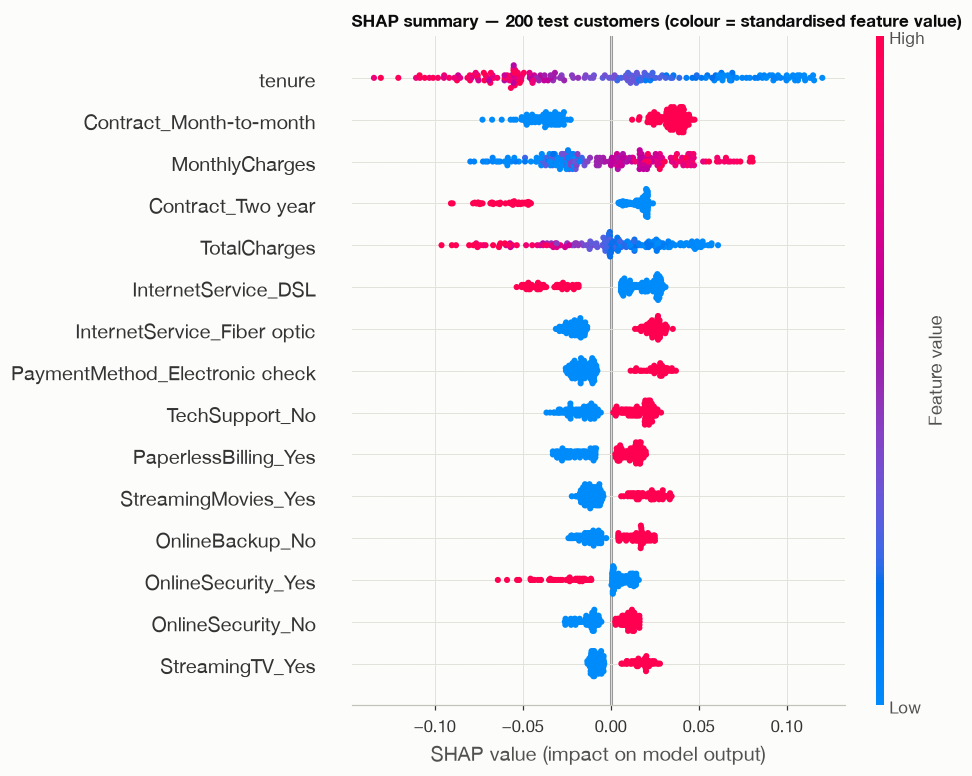

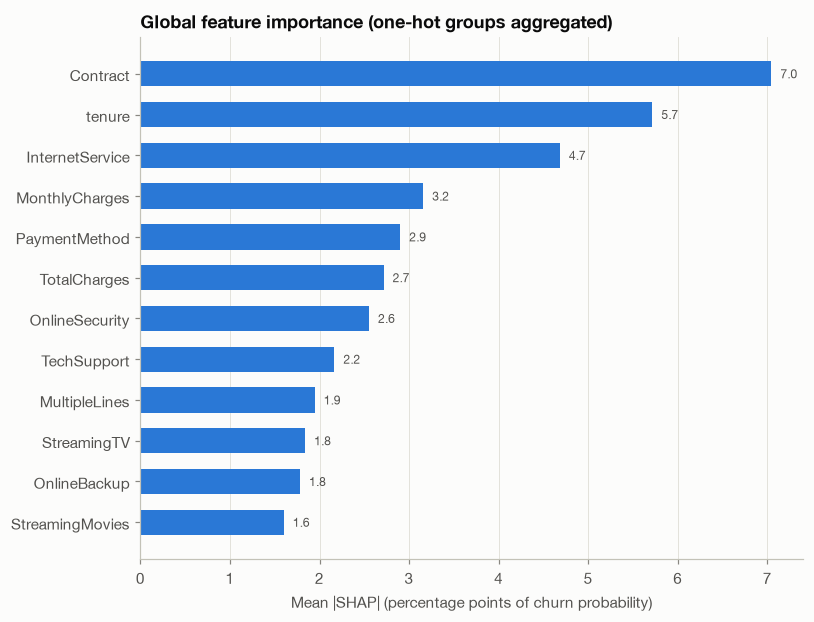

,mean |SHAP| (pp)
Contract,7.05
tenure,5.72
InternetService,4.68
MonthlyCharges,3.16
PaymentMethod,2.90
TotalCharges,2.72
OnlineSecurity,2.55
TechSupport,2.17
MultipleLines,1.95
StreamingTV,1.84


In [11]:
X_test_df = pd.DataFrame(X_explain, columns=feature_names)
shap.summary_plot(shap_matrix, X_test_df, show=False, max_display=15, plot_size=(9, 7))
plt.title('SHAP summary — 200 test customers (colour = standardised feature value)', loc='left', fontsize=11)
plt.savefig(config.PLOTS_DIR / 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

importance = explainer.global_importance(shap_matrix)
fig = P.plot_global_importance(importance)
P.save_figure(fig, config.PLOTS_DIR / 'shap_global_importance.png')
plt.show()
(importance * 100).round(2).rename('mean |SHAP| (pp)').to_frame().head(10)

### Customer-level drivers — `get_customer_top_drivers`
Returns the five features that push *this* customer's churn probability up (+) or down (−), with one-hot groups summed back into business concepts.

Highest-risk test customer: 5178-LMXOP — calibrated churn probability 85.5% (base rate 27.5%)


,feature,value,impact_pp,direction
0,tenure,1 month,11.13,increases
1,Contract,Month-to-month,6.79,increases
2,InternetService,Fiber optic,5.33,increases
3,MonthlyCharges,95.10,4.95,increases
4,TotalCharges,95.10,4.93,increases


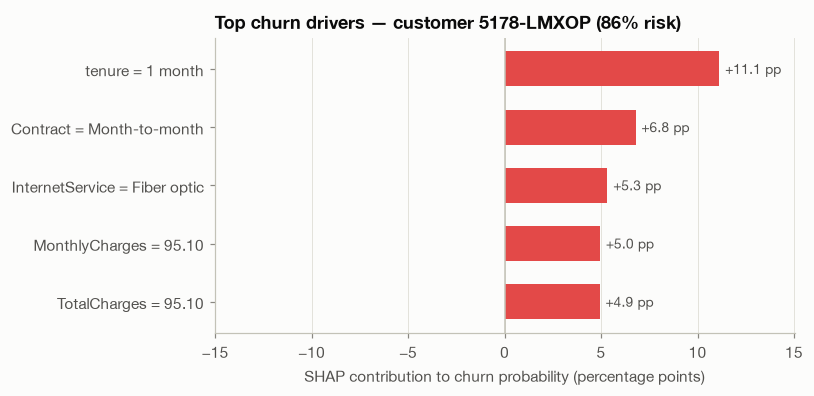

Lowest-risk test customer: 8224-KDLKN — calibrated churn probability 0.4% (base rate 27.5%)


,feature,value,impact_pp,direction
0,Contract,Two year,-7.12,decreases
1,tenure,72 months,-5.52,decreases
2,InternetService,No,-2.28,decreases
3,MonthlyCharges,25.00,-1.76,decreases
4,PaymentMethod,Bank transfer (automatic),-1.58,decreases


In [12]:
test_clean = pd.read_csv(config.PROCESSED_DIR / 'test_clean.csv')     # same row order as X_test
assert len(test_clean) == len(X_test)

for title, idx in [('Highest-risk test customer', int(np.argmax(p_mlp))),
                   ('Lowest-risk test customer', int(np.argmin(p_mlp)))]:
    record = test_clean.iloc[idx].to_dict()
    drivers = get_customer_top_drivers(X_test[idx], explainer, raw_record=record, top_k=5)
    print(f"{title}: {record['customerID']} — calibrated churn probability {p_mlp[idx]:.1%} "
          f"(base rate {explainer.base_value:.1%})")
    display(pd.DataFrame(drivers)[['feature', 'value', 'impact_pp', 'direction']])
    if title.startswith('Highest'):
        fig = P.plot_driver_bars(drivers, f'Top churn drivers — customer {record["customerID"]} ({p_mlp[idx]:.0%} risk)')
        P.save_figure(fig, config.PLOTS_DIR / 'shap_customer_example.png')
        plt.show()

### Reading the explanations
* **Global drivers** (mean |SHAP|) mirror the EDA: contract type, tenure and internet-service type dominate, followed by charges, payment method and the security/support add-ons.
* **Local drivers** answer the retention team's question *"why is this customer flagged, and what could we change?"* — e.g. a month-to-month contract and missing tech support are actionable (offer a discounted annual plan, bundle support), whereas short tenure is not.
* SHAP explains the *model*, not causality: a strong contribution means the model relies on that feature, not that changing it will necessarily change the customer's behaviour.